# BLUF

IMPORTS

In [41]:
#Imports
from datasets import load_dataset
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import evaluate
import torch
from tqdm import tqdm
import os
import re
import gc

#NLP Libraries
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, EncoderDecoderModel, Seq2SeqTrainingArguments, Seq2SeqTrainer
from collections import Counter
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import torch
import torch.nn as nn
from transformers import BertModel, TrainingArguments, Trainer, EarlyStoppingCallback, pipeline
from datasets import Dataset
from sklearn.linear_model import Ridge

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from transformers import AutoTokenizer, BertModel, AutoModelForSeq2SeqLM
from transformers.modeling_outputs import BaseModelOutput


In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

SETUP AND DATA EXPLORATION

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Targeting accelerated compute cluster: [{device.upper()}]")

Targeting accelerated compute cluster: [CUDA]


In [3]:
#Load the dataset from Hugging Face
dataset = load_dataset("knkarthick/samsum")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/9.26M [00:00<?, ?B/s]

validation.csv:   0%|          | 0.00/504k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/522k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

In [4]:
#Split the dataset into train, validation, and test pandas dataframes

train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14731 entries, 0 to 14730
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        14731 non-null  object
 1   dialogue  14731 non-null  object
 2   summary   14731 non-null  object
dtypes: object(3)
memory usage: 345.4+ KB


In [5]:
#Take a look at the first few rows of the training dataframe
train_df.head()

,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\nSam: i...,"Sam is confused, because he overheard Rick com..."


In [6]:
#Statistics about the training dataframe
train_df.describe(), train_df.isnull().sum(),train_df.duplicated().sum()

(              id                                           dialogue  \
 count      14731                                              14731   
 unique     14731                                              14255   
 top     13729017  Jimmy: Hey, guess what? My car's completely ka...   
 freq           1                                                  4   
 
                                                   summary  
 count                                               14731  
 unique                                              14729  
 top     Seth's pet Oreo that he got when he was 10 is ...  
 freq                                                    2  ,
 id          0
 dialogue    0
 summary     0
 dtype: int64,
 np.int64(0))

In [7]:
# Word and Character Counts for chat logs
train_df["dialogue_word_count"] = train_df["dialogue"].apply(lambda x: len(x.split()))
train_df["dialogue_char_count"] = train_df["dialogue"].apply(len)

# For the human written summaries
train_df["summary_word_count"] = train_df["summary"].apply(lambda x: len(x.split()))
train_df["summary_char_count"] = train_df["summary"].apply(len)

# Pipeline Insights for Technical Design
print("\n--- Pipeline Configuration Insights ---")
print(f"• Average chat length is {train_df['dialogue_word_count'].mean():.1f} words.")
print(f"• 95% of dialogues are under {train_df['dialogue_word_count'].quantile(0.95):.0f} words.")
print(f"• Target human summaries average {train_df['summary_word_count'].mean():.1f} words.")


--- Pipeline Configuration Insights ---
• Average chat length is 93.8 words.
• 95% of dialogues are under 237 words.
• Target human summaries average 20.3 words.


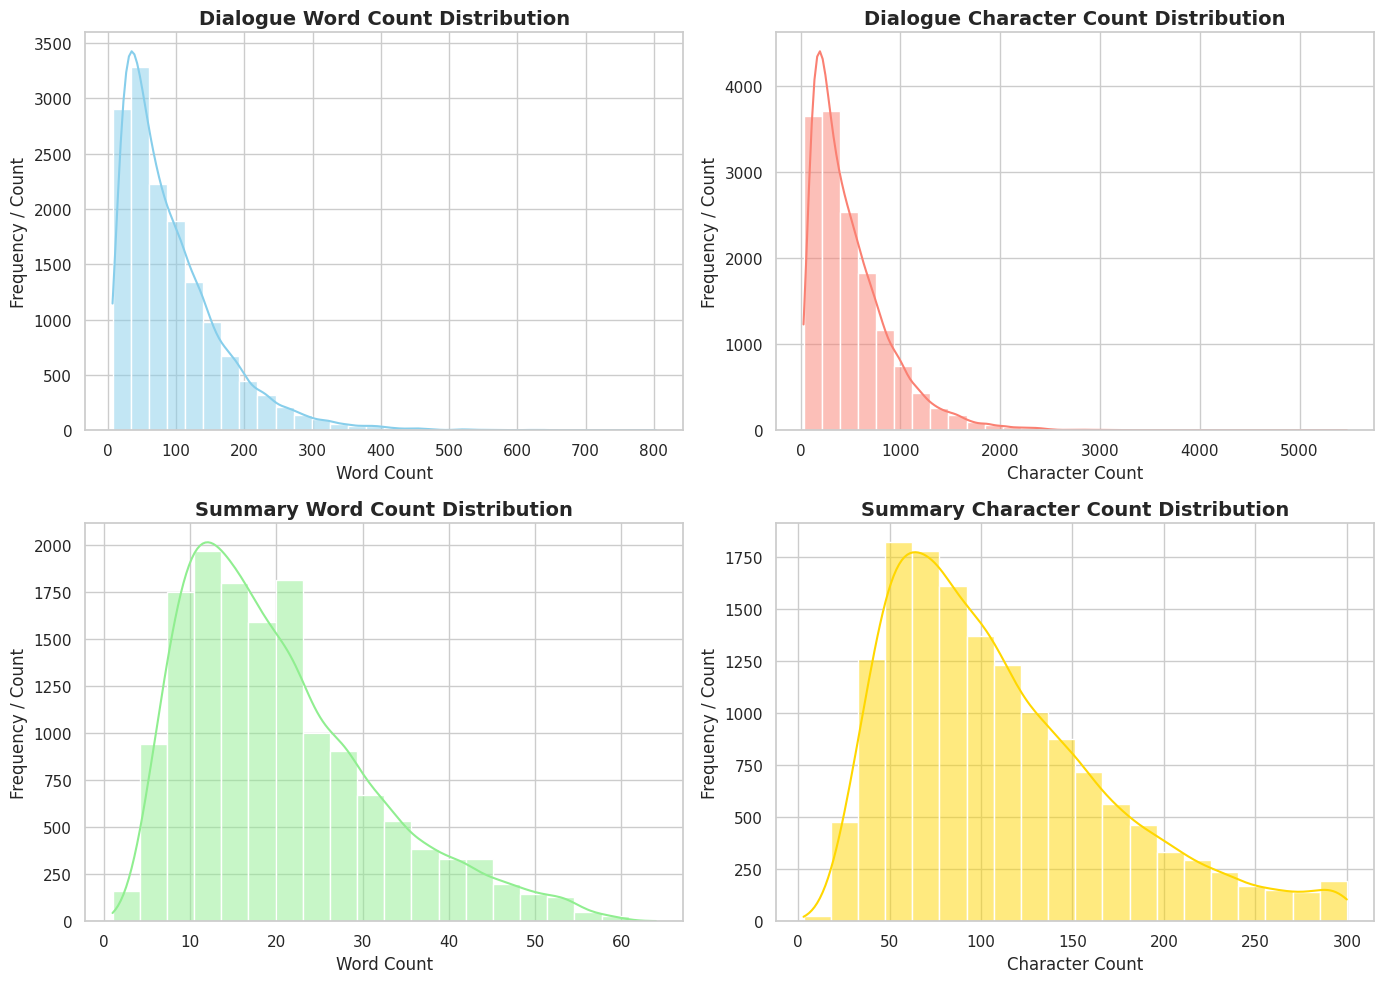

In [8]:
# Visualize the distributions of dialogue and summary lengths
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dialogue Word Count Distribution
sns.histplot(train_df['dialogue_word_count'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Dialogue Word Count Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Word Count', fontsize=12)
axes[0, 0].set_ylabel('Frequency / Count', fontsize=12)

# Dialogue Character Count Distribution
sns.histplot(train_df['dialogue_char_count'], bins=30, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Dialogue Character Count Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Character Count', fontsize=12)
axes[0, 1].set_ylabel('Frequency / Count', fontsize=12)

# Summary Word Count Distribution
sns.histplot(train_df['summary_word_count'], bins=20, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Summary Word Count Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Word Count', fontsize=12)
axes[1, 0].set_ylabel('Frequency / Count', fontsize=12)

# Summary Character Count Distribution
sns.histplot(train_df['summary_char_count'], bins=20, kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Summary Character Count Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Character Count', fontsize=12)
axes[1, 1].set_ylabel('Frequency / Count', fontsize=12)

plt.tight_layout()
plt.savefig('samsum_text_distributions.png', dpi=300)

In [9]:
# Count how many times a name appears followed by a colon (speaker turns)
train_df['speaker_turns'] = train_df['dialogue'].apply(lambda x: len(re.findall(r'(?:^|\n)[A-Z][a-zA-Z0-9\s]+:', x)))

# Extract unique speaker names per dialogue to find group chat sizes
def get_unique_speakers(text):
    # Matches patterns like "John:" or "Mary:" at the start of a line
    speakers = re.findall(r'(?:^|\n)([A-Z][a-zA-Z0-9\s]+):', text)
    return len(set([s.strip() for s in speakers]))

train_df['unique_speakers'] = train_df['dialogue'].apply(get_unique_speakers)

print("--- Conversational Information ---")
print(f"Average speaker turns per chat: {train_df['speaker_turns'].mean():.1f}")
print(f"Max speaker turns in a single chat: {train_df['speaker_turns'].max()}")
print(f"Average unique participants: {train_df['unique_speakers'].mean():.1f}")
print(f"Max unique participants (Group size): {train_df['unique_speakers'].max()}")

--- Conversational Information ---
Average speaker turns per chat: 11.1
Max speaker turns in a single chat: 46
Average unique participants: 2.4
Max unique participants (Group size): 14


TEXT PREPROCESSING

In [10]:
# Load the separate tokenizers
encoder_checkpoint = "bert-base-uncased"
decoder_checkpoint = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(encoder_checkpoint)
# GPT-2 needs a padding token defined since it doesn't have a default one
decoder_tokenizer = AutoTokenizer.from_pretrained(decoder_checkpoint)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token
decoder_tokenizer.pad_token = decoder_tokenizer.pad_token or decoder_tokenizer.eos_token

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [23]:
def standardize_dialogue(text):
    # 1. Break the dialogue into individual lines
    lines = text.split('\n')
    cleaned_lines = []
    
    # Track unique speakers in the order they appear
    speaker_map = {}
    speaker_count = 1
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        # Regex to find names/letters at the start of a line ending with a colon (e.g., "Emma:", "A:", "Tom:")
        match = re.match(r'^([A-Za-z0-9\s_\-\.]+)\s*:', line)
        
        if match:
            raw_speaker = match.group(1).strip()
            # If we haven't seen this speaker yet, assign them a clean tag
            if raw_speaker not in speaker_map:
                speaker_map[raw_speaker] = f"Speaker {speaker_count}"
                speaker_count += 1
            
            # Replace the old name with the clean normalized name
            normalized_name = speaker_map[raw_speaker]
            line_content = line[match.end():].strip()
            cleaned_lines.append(f"{normalized_name}: {line_content}")
        else:
            # If a line doesn't match the pattern, keep it as text continuation
            cleaned_lines.append(line)
            
    # Rejoin lines with a clean space
    return " ".join(cleaned_lines)

In [ ]:
def preprocess_function(examples):
    # Apply our standardization logic to every dialogue row
    standardized_dialogues = [standardize_dialogue(text) for text in examples["dialogue"]]

    prefix = "Summarize the following dialogue:\n\n"
    
    instructed_dialogues = [
        prefix + re.sub(r'\s+', ' ', text.replace('\n', ' ')).strip() 
        for text in standardized_dialogues
    ]
    
    # 1. Tokenize the input using the BERT encoder tokenizer
    model_inputs = tokenizer(instructed_dialogues, max_length=384, padding="max_length", truncation=True)    # Increased to 384 to accommodate longer dialogues while still enforcing a hard ceiling
    
    # 2. Tokenize the target summaries using the GPT-2 decoder tokenizer
    labels = decoder_tokenizer(text=examples["summary"], max_length=90, padding="max_length", truncation=True)
    
    # Replace pad tokens with -100 so the PyTorch loss function ignores them
    model_inputs["labels"] = [[(t if t != decoder_tokenizer.pad_token_id else -100) for t in seq] for seq in labels["input_ids"]]
    return model_inputs

In [35]:
# Map your dataset splits using this new multi-tokenizer strategy
train_data = dataset["train"].shuffle(seed=42).select(range(7000)).map(preprocess_function, batched=True)
eval_data = dataset["validation"].shuffle(seed=42).map(preprocess_function, batched=True)

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

In [33]:
# 1. Grab a raw sample directly from your training data
raw_sample_dialogue = dataset["validation"][5]["dialogue"]

# 2. Run it through your speaker standardization function manually
standardized_sample = standardize_dialogue(raw_sample_dialogue)

print("--- STEP 1: RAW VS STANDARDIZED TEXT ---")
print(f"👉 RAW:\n{raw_sample_dialogue[:200]}...\n")
print(f"👉 STANDARDIZED:\n{standardized_sample[:200]}...\n")
print("-" * 50)

# 3. Simulate exactly what the encoder tokenizer does
prompt = f"Task: Summarize the following chat.\nContext:\n{standardized_sample}\nSummary:"
encoded = tokenizer(prompt, max_length=256, padding="max_length", truncation=True)

# 4. Decode it back using the ENCODER tokenizer to see what the model reads
decoded_input_string = tokenizer.decode(encoded["input_ids"], skip_special_tokens=False)

print("--- STEP 2: WHAT THE ENCODER ACTUALLY SEES ---")
print(decoded_input_string[:400])
print("-" * 50)

--- STEP 1: RAW VS STANDARDIZED TEXT ---
👉 RAW:
Keith: Meg, pls buy some milk and cereals, I see now we've run out of them
Megan: hm, sure, I can do that
Megan: but did you check in the drawer next to the fridge?
Keith: nope, let me have a look
Kei...

👉 STANDARDIZED:
Speaker 1: Meg, pls buy some milk and cereals, I see now we've run out of them Speaker 2: hm, sure, I can do that Speaker 2: but did you check in the drawer next to the fridge? Speaker 1: nope, let me...

--------------------------------------------------
--- STEP 2: WHAT THE ENCODER ACTUALLY SEES ---
[CLS] task : summarize the following chat. context : speaker 1 : meg, pls buy some milk and cereals, i see now we ' ve run out of them speaker 2 : hm, sure, i can do that speaker 2 : but did you check in the drawer next to the fridge? speaker 1 : nope, let me have a look speaker 1 : ok, false alarm, we have cereal and milk : d speaker 2 : < file _ gif > summary : [SEP] [PAD] [PAD] [PAD] [PAD] [PAD
---------------------------

MODEL

In [13]:
# Build the hybrid cross-architecture model
model = EncoderDecoderModel.from_encoder_decoder_pretrained(encoder_checkpoint, decoder_checkpoint)

# CRITICAL CONFIGURATION: Set the special token mappings for generation
model.config.decoder_start_token_id = decoder_tokenizer.bos_token_id
model.config.pad_token_id = decoder_tokenizer.pad_token_id
model.config.eos_token_id = decoder_tokenizer.eos_token_id
model.config.vocab_size = model.config.decoder.vocab_size

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                                                 | Status     | 
----------------------------------------------------+------------+-
h.{0...11}.attn.bias                                | UNEXPECTED | 
transformer.h.{0...11}.ln_cross_attn.weight         | MISSING    | 
transformer.h.{0...11}.crossattention.c_proj.bias   | MISSING    | 
transformer.h.{0...11}.ln_cross_attn.bias           | MISSING    | 
transformer.h.{0...11}.crossattention.c_proj.weight | MISSING    | 
transformer.h.{0...11}.crossattention.q_attn.weight | MISSING    | 
transformer.h.{0...11}.crossattention.c_attn.bias   | MISSING    | 
transformer.h.{0...11}.crossattention.c_attn.weight | MISSING    | 
transformer.h.{0...11}.crossattention.q_attn.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

FINE TUNING MODEL

In [36]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./bert_gpt2_summarizer",
    per_device_train_batch_size=4,       # Keep train batch size small to save GPU memory during fine-tuning
    per_device_eval_batch_size=4,        # Keep eval batch size small to save GPU memory during validation
    gradient_accumulation_steps=4,       # Simulates a stable batch size of 16
    eval_strategy="epoch",               # Evaluate every epoch
    save_strategy="epoch",               # Save a checkpoint every epoch
    learning_rate=3e-5,                  # Steady learning rate for fine-tuning
    num_train_epochs=5,                 # Higher epoch count to allow for early stopping to kick in
    weight_decay=0.01,                    
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    
    # --- EARLY STOPPING & SAVING STRATEGY ---
    load_best_model_at_end=True,         # At the end of training, automatically reload the best weights
    metric_for_best_model="eval_loss",   # Use validation loss to determine what "best" means
    greater_is_better=False,             # For loss, lower numbers are better
    save_total_limit=1,                  # Keep only the best checkpoint on your disk to save space
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=eval_data,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)] 
)

In [37]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Epoch,Training Loss,Validation Loss
1,11.472480,3.393102
2,10.802032,3.434559


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


TrainOutput(global_step=876, training_loss=11.173545872239762, metrics={'train_runtime': 780.0863, 'train_samples_per_second': 44.867, 'train_steps_per_second': 2.807, 'total_flos': 6421183856640000.0, 'train_loss': 11.173545872239762, 'epoch': 2.0})

In [38]:
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

EncoderDecoderModel(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elemen

EVALUATION AND ANALYSIS

In [39]:
print("--- GENERATING SUMMARIES FROM VALIDATION DATA ---\n")

# 2. Select a slice of your actual validation dataset (e.g., the first 3 rows)
num_samples_to_test = 3

# Test on the first 3 validation rows
num_samples_to_test = 3

for i in range(num_samples_to_test):
    actual_dialogue = dataset["validation"][i]["dialogue"]
    true_summary = dataset["validation"][i]["summary"]
    
    # Keep the prompt clean and tight
    prompt = f"Summarize the following dialogue:\n\n{actual_dialogue}\n\nSummary:"
    
    # Tokenize input using the BERT encoder tokenizer
    inputs = tokenizer(prompt, return_tensors="pt", max_length=256, truncation=True).to(model.device)
    
    with torch.no_grad():
        output_tokens = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            
            decoder_start_token_id=decoder_tokenizer.bos_token_id,
            pad_token_id=decoder_tokenizer.pad_token_id,
            eos_token_id=decoder_tokenizer.eos_token_id,
            
            # --- COMBINED: LOWER TEMPERATURE & SHORTER CEILING ---
            max_length=25,               # Dropped to 25 to force punchy, target-length summaries
            do_sample=True,
            temperature=0.1,             # Lowered to 0.1 for maximum factual determinism
            num_beams=2,                 # Kept tight to prevent complex hallucination tracking
            
            # --- AGGRESSIVE REPETITION BARRIERS ---
            no_repeat_ngram_size=2,      
            repetition_penalty=3.5,      # Increased to 3.5 to completely break name-looping ("Maria wants Maria")
            early_stopping=True
        )
    
    # Decode using the GPT-2 decoder tokenizer
    predicted_summary = decoder_tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    
    # Clean up the output in case it includes the prompt or trailing text
    predicted_summary = predicted_summary.strip()

    # 7. Print the comparison
    print(f"--- SAMPLE #{i+1} ---")
    print(f"RAW DIALOGUE:\n{actual_dialogue}\n")
    print(f"GROUND TRUTH (Human Summary):\n{true_summary}\n")
    print(f"MODEL PREDICTION:\n{predicted_summary}\n")
    print("="*50 + "\n")

--- GENERATING SUMMARIES FROM VALIDATION DATA ---

--- SAMPLE #1 ---
RAW DIALOGUE:
A: Hi Tom, are you busy tomorrow’s afternoon?
B: I’m pretty sure I am. What’s up?
A: Can you go with me to the animal shelter?.
B: What do you want to do?
A: I want to get a puppy for my son.
B: That will make him so happy.
A: Yeah, we’ve discussed it many times. I think he’s ready now.
B: That’s good. Raising a dog is a tough issue. Like having a baby ;-) 
A: I'll get him one of those little dogs.
B: One that won't grow up too big;-)
A: And eat too much;-))
B: Do you know which one he would like?
A: Oh, yes, I took him there last Monday. He showed me one that he really liked.
B: I bet you had to drag him away.
A: He wanted to take it home right away ;-).
B: I wonder what he'll name it.
A: He said he’d name it after his dead hamster – Lemmy  - he's  a great Motorhead fan :-)))

GROUND TRUTH (Human Summary):
A will go to the animal shelter tomorrow to get a puppy for her son. They already visited the shel